In [1]:
import pandas as pd
import re

with open("vicwords.txt", "r", encoding="utf-8-sig") as f:
    text = f.read()

sentences = re.split(r'(?<=[.!?])\s+', text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

df = pd.DataFrame({"text": sentences})

print("Rows:", len(df))
print("Columns:", df.shape[1])
df.head()


Rows: 1229
Columns: 1


,text
0,The Philippines is an island country consistin...
1,"It was named after King Philip II, who was kin..."
2,Spain held authority in the Philippines for 33...
3,As a result of the extended period of time und...
4,Even after the United States granted sovereign...


In [2]:
df["clean_text"] = df["text"].str.lower()
df["clean_text"].head()

0    the philippines is an island country consistin...
1    it was named after king philip ii, who was kin...
2    spain held authority in the philippines for 33...
3    as a result of the extended period of time und...
4    even after the united states granted sovereign...
Name: clean_text, dtype: str

In [3]:
def clean_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

df["clean_text"] = df["clean_text"].apply(clean_text)

df["clean_text"].head()

0    the philippines is an island country consistin...
1    it was named after king philip ii who was king...
2    spain held authority in the philippines for ye...
3    as a result of the extended period of time und...
4    even after the united states granted sovereign...
Name: clean_text, dtype: str

In [4]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())
df["tokens"].head()

0    [the, philippines, is, an, island, country, co...
1    [it, was, named, after, king, philip, ii, who,...
2    [spain, held, authority, in, the, philippines,...
3    [as, a, result, of, the, extended, period, of,...
4    [even, after, the, united, states, granted, so...
Name: tokens, dtype: object

In [5]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(tokens):
    return [word for word in tokens if word not in ENGLISH_STOP_WORDS]

df["tokens"] = df["tokens"].apply(remove_stopwords)

print(df["tokens"][0])

['philippines', 'island', 'country', 'consisting', 'islands', 'islets', 'southeast', 'asia']


In [6]:
from sklearn.feature_extraction.text import CountVectorizer

documents = []
for i in range(0, len(df), 10):
    chunk = df["clean_text"].iloc[i:i+10]
    documents.append(" ".join(chunk))

print(f"Number of documents: {len(documents)}")

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)

bow_df = pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())

Number of documents: 123


In [7]:
word_counts = bow_df.sum(axis=0)

word_counts_sorted = word_counts.sort_values(ascending=False)

import matplotlib.pyplot as plt

vectorizer = CountVectorizer(stop_words='english')
bow_matrix = vectorizer.fit_transform(documents)

bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

word_counts = bow_df.sum(axis=0).sort_values(ascending=False)
print(word_counts.head(15))

people        110
states         75
united         64
black          59
paul           58
new            50
war            50
house          49
american       42
soviet         42
like           37
does           35
time           35
government     35
labor          32
dtype: int64


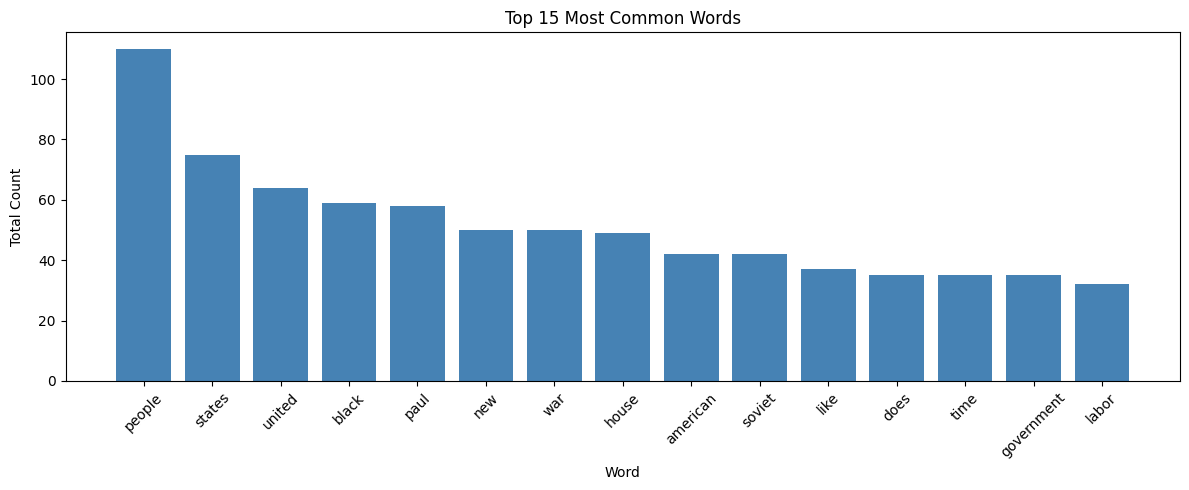

In [8]:
top_words = bow_df.sum(axis=0).sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_words.index, top_words.values, color='steelblue')
plt.title("Top 15 Most Common Words")
plt.xlabel("Word")
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

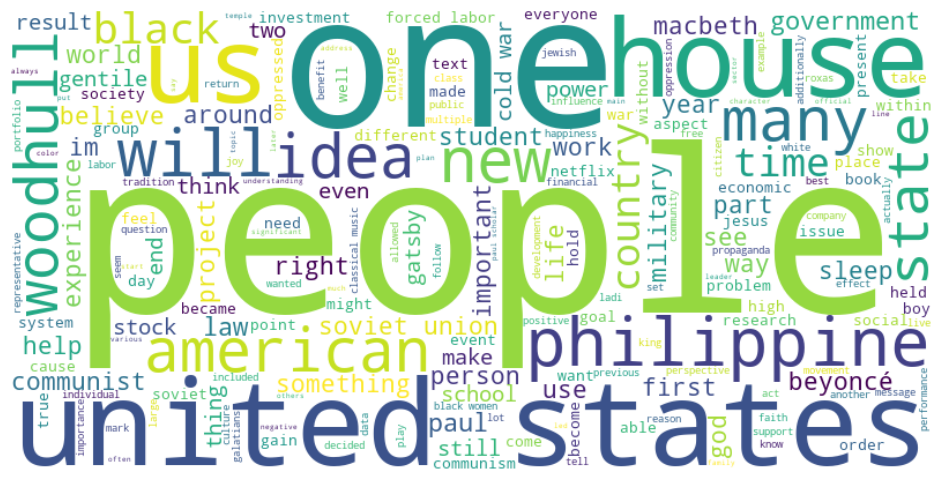

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english', 
    max_features=100
)

tfidf_matrix = tfidf.fit_transform(documents)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,able,american,aspects,believe,beyoncé,black,book,boy,cause,class,...,wanted,war,way,white,women,woodhull,work,world,year,years
0,0.000000,0.135740,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.131159,0.000000,0.0,0.0,0.0,0.0,0.062508,0.000000,0.152881
1,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.081248,0.000000,0.0,0.0,0.0,0.0,0.077443,0.000000,0.094703
2,0.074606,0.070547,0.081306,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.272665,0.000000,0.0,0.0,0.0,0.0,0.129947,0.085479,0.000000
3,0.000000,0.064163,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.123995,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
4,0.105144,0.298269,0.000000,0.0,0.0,0.0,0.0,0.0,0.109549,0.0,...,0.0,0.000000,0.099423,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000


### TF-IDF tells us how many times a word appears in a document out of the total words in that document. It isn't a simple count.

In [11]:
top_tfidf = tfidf_df.sum(axis=0).sort_values(ascending=False).head(20)
top_tfidf

people        8.950349
new           6.688636
house         6.622324
paul          6.357293
states        5.995328
black         5.623043
united        5.574790
like          5.214855
war           5.174683
american      5.130800
im            5.040604
labor         4.954335
work          4.900316
research      4.836037
woodhull      4.541729
government    4.499258
time          4.343404
gatsby        4.248432
did           4.078532
different     4.065507
dtype: float64

### People is still at the top, but words like united and states fell slightly in importance. Gatsby and research appeared.

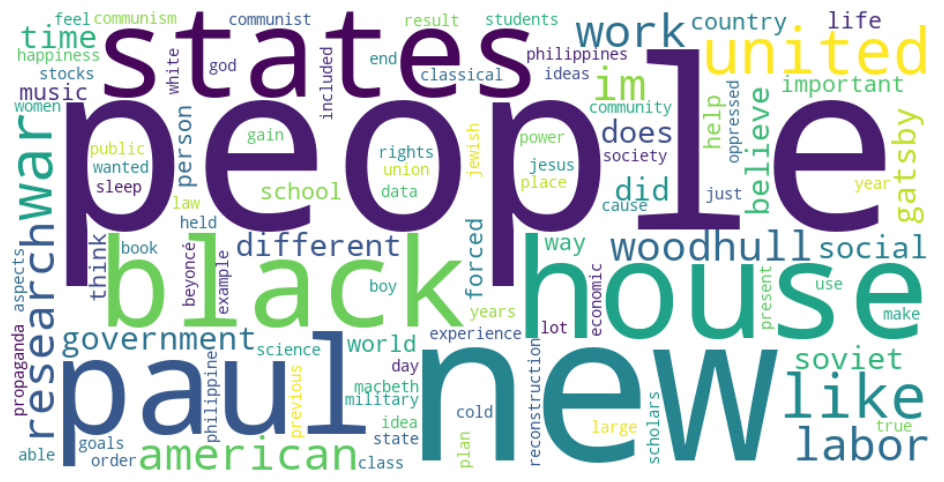

In [15]:
tdidf = tfidf_df.sum(axis=0).to_dict()

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(tdidf)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### I wrote a lot about the United States and its history. Most of my essay work is historical. I don't use like excessively, but I say did too much. I need another synonym for people.

TF-IDF matrix shape: (1229, 500)


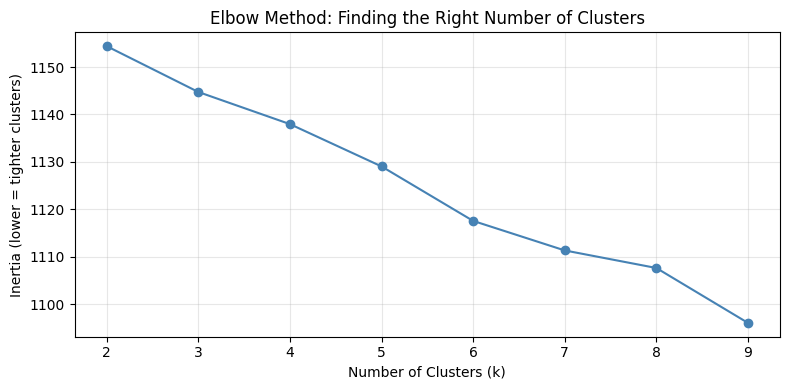

Look for the elbow — where the curve bends and flattens.
That k value is usually a good choice.

TOP WORDS PER CLUSTER

Cluster 0 (894 documents)
Top words: macbeth, work, way, american, war, time, sleep, like, government, gatsby
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 1 (37 documents)
Top words: house, woodhull, year, head, school, representative, immediately, couple, held, points
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 2 (67 documents)
Top words: paul, new, law, galatians, scholars, old, perspective, gentile, writes, does
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 3 (75 documents)
Top words: united, states, soviet, union, war, philippines, propaganda, cold, power, military
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 4 (110 docu

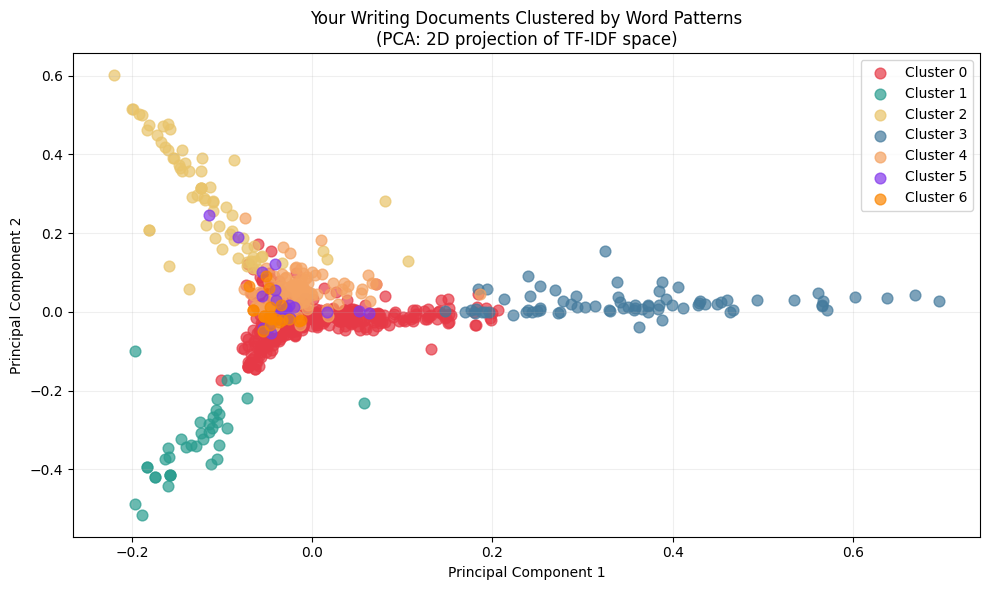

Each dot = one document. Dots close together = similar word patterns.

Similarity matrix shape: (1229, 1229)

Sample (first 4 documents vs first 4):
[[1.    0.    0.162 0.339]
 [0.    1.    0.    0.053]
 [0.162 0.    1.    0.128]
 [0.339 0.053 0.128 1.   ]]
Diagonal is always 1.0 — every document is identical to itself



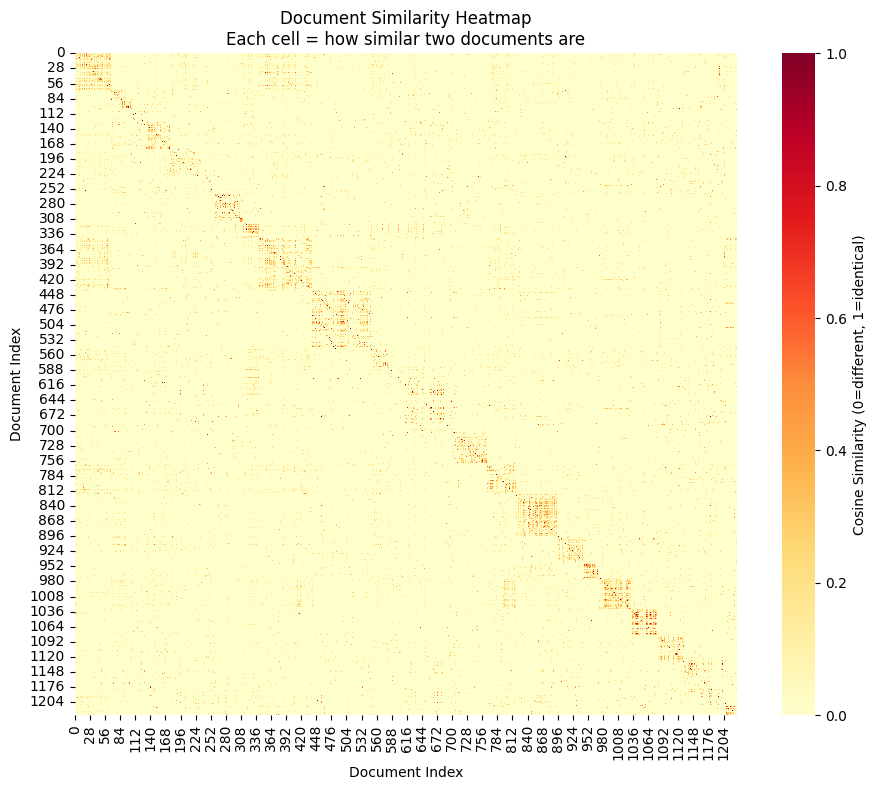

Bright red = very similar. Pale yellow = very different.

YOUR MOST SIMILAR DOCUMENT PAIR
Score: 1.000

Document 443:
  anton fleissner was the assistant head of house...

Document 489:
  anton fleissner was the assistant head of house...

Question: why do you think these two are so similar?

YOUR LEAST SIMILAR DOCUMENT PAIR
Score: 0.000

Document 0:
  the philippines is an island country consisting of more than islands and islets in southeast asia...

Document 1:
  it was named after king philip ii who was king at the time of spanish colonial rule in the th century...

Question: what makes these two so different?

Source document [0]:
  the philippines is an island country consisting of more than islands and islets in southeast asia...

Top 5 most similar documents:

  [1] Similarity: 0.676
       simply lost interest in holding the island country the united states had the power to send the philippines into disarray...

  [2] Similarity: 0.600
       even after the united states grant

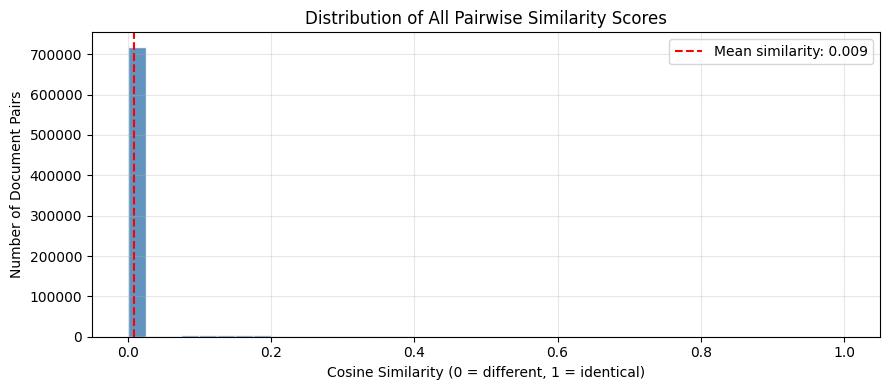

Average similarity across all pairs: 0.009
Most similar pair:  1.000
Least similar pair: 0.000

Reflection questions:
  - Is your writing more similar overall, or more varied?
  - Does this match your own sense of how diverse your topics are?
  - Which pair surprised you most?


In [19]:
# ============================================================
# FULL PIPELINE: K-MEANS CLUSTERING + COSINE SIMILARITY
# Starting point: you have df with 'clean_text' and tfidf_matrix
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# REBUILD TFIDF (skip if you already have tfidf_matrix + vectorizer)
# ============================================================

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# ============================================================
# SECTION 1: ELBOW METHOD — find the right number of clusters
# ============================================================

inertia_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_scores, marker='o', color='steelblue')
plt.title('Elbow Method: Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(cluster_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the elbow — where the curve bends and flattens.")
print("That k value is usually a good choice.\n")

# ============================================================
# SECTION 2: RUN K-MEANS with your chosen number of clusters
# ============================================================

NUM_CLUSTERS = 7  # change this after looking at the elbow plot

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_

# ============================================================
# SECTION 3: TOP WORDS PER CLUSTER
# ============================================================

print("=" * 50)
print("TOP WORDS PER CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    center = kmeans.cluster_centers_[cluster_num]
    top_word_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    doc_count = (df['cluster'] == cluster_num).sum()
    print(f"\nCluster {cluster_num} ({doc_count} documents)")
    print(f"Top words: {', '.join(top_words)}")
    print("Your job: give this cluster a name based on these words!")
    print("-" * 40)

# ============================================================
# SECTION 4: CLUSTER METRICS
# ============================================================

sil = silhouette_score(tfidf_matrix, df['cluster'])
db = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster'])

print("\n" + "=" * 50)
print("CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"\nSilhouette Score: {sil:.3f}")
print("  > 0.5 = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2 = weak or overlapping clusters")
print(f"\nDavies-Bouldin Score: {db:.3f}")
print("  Closer to 0 = better separated clusters")
print(f"\nDocuments per cluster:")
print(df['cluster'].value_counts().sort_index())
print("If one cluster has 90% of documents, try a different k\n")

# ============================================================
# SECTION 5: SAMPLE DOCUMENTS FROM EACH CLUSTER
# ============================================================

print("=" * 50)
print("SAMPLE DOCUMENTS FROM EACH CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    print(f"\n--- Cluster {cluster_num} ---")
    samples = df[df['cluster'] == cluster_num]['clean_text'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"  [{i}] {text[:200]}...")

# ============================================================
# SECTION 6: PCA SCATTER PLOT — visualize clusters in 2D
# ============================================================

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

plot_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'cluster': df['cluster'].astype(str)
})

colors = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#f4a261', '#8338ec','#fb8500', '#023047', '#06d6a0']
plt.figure(figsize=(10, 6))
for cluster_num in range(NUM_CLUSTERS):
    subset = plot_df[plot_df['cluster'] == str(cluster_num)]
    plt.scatter(subset['x'], subset['y'],
                label=f'Cluster {cluster_num}',
                alpha=0.7, s=60, color=colors[cluster_num])

plt.title('Your Writing Documents Clustered by Word Patterns\n(PCA: 2D projection of TF-IDF space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Each dot = one document. Dots close together = similar word patterns.\n")

# ============================================================
# SECTION 7: BUILD COSINE SIMILARITY MATRIX
# ============================================================

similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)
print(f"\nSample (first 4 documents vs first 4):")
print(np.round(similarity_matrix[:4, :4], 3))
print("Diagonal is always 1.0 — every document is identical to itself\n")

# ============================================================
# SECTION 8: SIMILARITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1,
            square=True,
            cbar_kws={'label': 'Cosine Similarity (0=different, 1=identical)'})
plt.title('Document Similarity Heatmap\nEach cell = how similar two documents are')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()
print("Bright red = very similar. Pale yellow = very different.\n")

# ============================================================
# SECTION 9: MOST AND LEAST SIMILAR DOCUMENT PAIRS
# ============================================================

sim_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(sim_no_diagonal, 0)

most_similar_idx = np.unravel_index(np.argmax(sim_no_diagonal), sim_no_diagonal.shape)
doc_a, doc_b = most_similar_idx

sim_find_low = similarity_matrix.copy()
np.fill_diagonal(sim_find_low, 1)
least_similar_idx = np.unravel_index(np.argmin(sim_find_low), sim_find_low.shape)
doc_c, doc_d = least_similar_idx

print("=" * 50)
print("YOUR MOST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_a][doc_b]:.3f}")
print(f"\nDocument {doc_a}:\n  {df['clean_text'].iloc[doc_a][:300]}...")
print(f"\nDocument {doc_b}:\n  {df['clean_text'].iloc[doc_b][:300]}...")
print("\nQuestion: why do you think these two are so similar? - The Woodhull house histories I was writing was repetitive\n")

print("=" * 50)
print("YOUR LEAST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_c][doc_d]:.3f}")
print(f"\nDocument {doc_c}:\n  {df['clean_text'].iloc[doc_c][:300]}...")
print(f"\nDocument {doc_d}:\n  {df['clean_text'].iloc[doc_d][:300]}...")
print("\nQuestion: what makes these two so different? - The words are very different\n")

# ============================================================
# SECTION 10: FIND MOST SIMILAR DOCUMENTS TO A GIVEN DOCUMENT
# ============================================================

def find_most_similar(doc_index, similarity_matrix, df, top_n=5):
    scores = similarity_matrix[doc_index]
    sorted_indices = scores.argsort()[::-1]
    similar_indices = [i for i in sorted_indices if i != doc_index][:top_n]

    print(f"Source document [{doc_index}]:")
    print(f"  {df['clean_text'].iloc[doc_index][:250]}...\n")
    print(f"Top {top_n} most similar documents:\n")

    for rank, idx in enumerate(similar_indices, 1):
        print(f"  [{rank}] Similarity: {scores[idx]:.3f}")
        print(f"       {df['clean_text'].iloc[idx][:200]}...")
        print()

find_most_similar(doc_index=0, similarity_matrix=similarity_matrix, df=df)

# ============================================================
# SECTION 11: SEARCH YOUR OWN WRITING WITH A NEW QUERY
# ============================================================

def search_my_writing(query_text, vectorizer, tfidf_matrix, df, top_n=5):
    # transform() uses the existing vocabulary — NOT fit_transform()
    # fit_transform() would learn a new vocabulary from your query alone
    query_vector = vectorizer.transform([query_text])
    query_similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = query_similarities.argsort()[::-1][:top_n]

    print(f"Query: '{query_text}'")
    print(f"\nMost similar passages in your writing:\n")

    for rank, idx in enumerate(top_indices, 1):
        score = query_similarities[idx]
        if score == 0:
            print(f"  [{rank}] No similarity found (score: 0.000)")
            print(f"       This word may not be in your writing vocabulary")
        else:
            print(f"  [{rank}] Similarity: {score:.3f}")
            print(f"       {df['clean_text'].iloc[idx][:250]}...")
        print()

# Change this query to anything you want to search for in your writing
search_my_writing(
    query_text="jesus",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df
)

# ============================================================
# SECTION 12: DISTRIBUTION OF ALL PAIRWISE SIMILARITY SCORES
# ============================================================

upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
all_pair_scores = similarity_matrix[upper_triangle_indices]

plt.figure(figsize=(9, 4))
plt.hist(all_pair_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_pair_scores), color='red', linestyle='--',
            label=f'Mean similarity: {np.mean(all_pair_scores):.3f}')
plt.title('Distribution of All Pairwise Similarity Scores')
plt.xlabel('Cosine Similarity (0 = different, 1 = identical)')
plt.ylabel('Number of Document Pairs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average similarity across all pairs: {np.mean(all_pair_scores):.3f}")
print(f"Most similar pair:  {np.max(all_pair_scores):.3f}")
print(f"Least similar pair: {np.min(all_pair_scores):.3f}")
print()
print("Reflection questions:")
print("  - Is your writing more similar overall, or more varied? - My writing is pretty similar.")
print("  - Does this match your own sense of how diverse your topics are? - This does match my sense of how I write. I am interested in history, so I wrote through a historical lense often.")
print("  - Which pair surprised you most?")